# 1 assemble the system

In [1]:
import sys
sys.path.append('../utils/')
from utils_models import *
from scipy.optimize import curve_fit
import scipy
from scipy.special import erfc

from skimage.transform import radon

In [2]:
max_ql = 30
max_ol = 75
EJ = 3
EC = EJ/4
EL = EJ/20.5
Er = 8.46111172

g = 0.2
w_d = 8.460155465243822
amp = 0.003

tot_time =660
tlist = np.linspace(0, tot_time, tot_time)[::5]
kappa = 1e-3

system =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g, 
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in range(15) for ol in range(max_ol) ],
                computaional_states = '1,2',
                )

# 2 store the mcsolve jobs

In [3]:
from utils_mcsolve import *

state_leak_dressed = qutip.basis(max_ql * max_ol, system.product_to_dressed[(0,0)])

state_0_dressed = qutip.basis(max_ql * max_ol, system.product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(max_ql * max_ol, system.product_to_dressed[(2,0)])
state_plus_X_dressed = (state_0_dressed +  state_1_dressed).unit()
state_minus_X_dressed = (state_0_dressed - state_1_dressed).unit()
state_plus_Y_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_Y_dressed = (state_0_dressed - 1j * state_1_dressed).unit()

initial_states  = [
                    state_leak_dressed,
                   state_0_dressed,
                   state_1_dressed,
                   state_plus_X_dressed,
                   state_minus_X_dressed,
                   state_plus_Y_dressed,
                   state_minus_Y_dressed
                   ]

leakage_products_to_keep = [[ql, ol] for ql in [0,7] for ol in range(max_ol) ]
computational_products_to_keep = [[ql, ol] for ql in [1,2] for ol in range(max_ol) ]
list_of_products_to_keep = [
    leakage_products_to_keep,
    computational_products_to_keep,
    computational_products_to_keep,
    computational_products_to_keep,
    computational_products_to_keep,
    computational_products_to_keep,
    computational_products_to_keep
]


# ntraj_per_y0 = 3000
# chunk_size = 12
# existing_chunk_num = 0
# for y0, products_to_keep in zip(initial_states, list_of_products_to_keep):
#     system.set_new_product_to_keep(products_to_keep)
#     system.set_new_operators_after_setting_new_product_to_keep()
#     existing_chunk_num = pack_mcsolve_chunks(
#                     y0 = system.truncate_function(y0),
#                     tlist = tlist,
#                     static_hamiltonian = system.diag_dressed_hamiltonian,
#                     drive_terms = [DriveTerm( 
#                                 driven_op= system.driven_operator,
#                                 pulse_shape_func=square_pulse_with_rise_fall,
#                                 pulse_shape_args={
#                                     'w_d': w_d ,
#                                     'amp': amp,
#                                     't_rise': 20,
#                                     't_square': tot_time
#                                 })],                    
#                     c_ops = system.c_ops,
#                     e_ops = [system.a_trunc , system.a_trunc.dag()*system.a_trunc],
#                     ntraj = ntraj_per_y0,
#                     existing_chunk_num = existing_chunk_num,
#                     chunk_size = chunk_size)
    
# pack_pkl_files_to_zip()

# 3 sent to condor and run


# 4 load the mcsolve results, average them

In [16]:
zip_files = [f"zipped_results/result_{i}.zip" for i in range(1750)]
n_parts = len(initial_states)
part_length = len(zip_files) // n_parts
zip_file_parts = [zip_files[i * part_length : (i + 1) * part_length] for i in range(n_parts)]

zip_files = [f"zipped_results_first1000/result_{i}.zip" for i in range(1750)]
n_parts = len(initial_states)
part_length = len(zip_files) // n_parts
for i in range(n_parts):
    zip_file_parts[i].extend(zip_files[i * part_length : (i + 1) * part_length])

results = []
for part in zip_file_parts:
    results.append(merge_results(part))


progress: 100%|██████████| 500/500 [01:07<00:00,  7.36it/s]


In [17]:
with open('averaged.pkl', 'wb') as f:
    pickle.dump(results,f)

In [ ]:


# with open('mcsolve_result_0.03_d0.002_tomo/averaged.pkl', 'rb') as f:
    # results = pickle.load(f)

# use mcsolve_post_processing.py to get product basis

In [4]:

with open('mcsolve_results_with_product_basis_5000traj.pkl', 'rb') as f:
    results = pickle.load(f)


prefix = rf'$\kappa = 10^{{-3}}$'
first_dominant_freq =find_dominant_frequency(results[0].expect[0],tlist)
first_dominant_freq

-0.07261707988980717

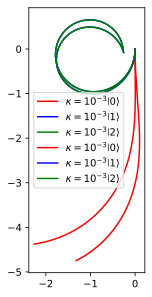

In [20]:
first_dominant_freq = -0.07295
colors = ['red','blue','green']
for i, result in enumerate(results[:3]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(alpha.real,alpha.imag,color=colors[i],label = prefix + rf'$\left|{i}\right>$')


first_dominant_freq = -0.0729
colors = ['red','blue','green']
for i, result in enumerate(results[:3]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    plt.plot(alpha.real,alpha.imag,color=colors[i],label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

In [6]:
lim = 15
xvec = np.linspace(-1*lim,lim,700)
X, Y = np.meshgrid(xvec, xvec)

In [15]:
frequency_used =  0.0729


(-5.0, 5.0)

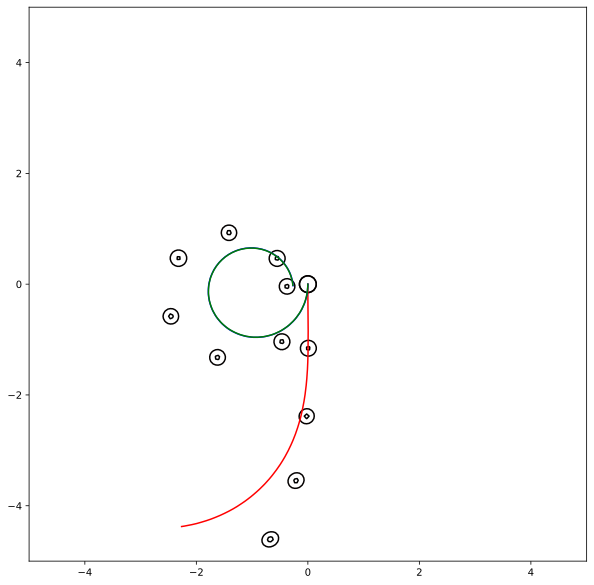

In [17]:
fig,ax = plt.subplots(figsize = (10,10))
for t_idx in [0,20,40,60,80,100,120,-1]:
    for ql in [0,1]:
        q_values = get_q_value(ql,t_idx)
        plot_qfunc_levels(ax, q_values,levels = [0.001,0.01])


for i, result in enumerate(results[:3]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    ax.plot(alpha.real,alpha.imag,color=colors[i])

ax.set_xlim(-5,5)
ax.set_ylim(-5,5)

In [44]:
def get_q_value(ql,t_idx):
    rho_product = results[ql].states_in_product_basis[t_idx]
    rho = qutip.Qobj(np.array(rho_product.ptrace(1)))
    U_inv = ( -1j  *  frequency_used * 2*np.pi * qutip.create(max_ol) * qutip.destroy(max_ol) * tlist[t_idx] ).expm().dag()  # Inverse rotation operator
    rho = U_inv * rho * U_inv.dag()

    rho = rho/rho.tr()
    rho = (rho + rho.dag()) / 2

    q_values = qutip.qfunc(rho, xvec, xvec)
    return q_values

def plot_qfunc_levels(ax, q_values,levels = [0.001,0.5,0.99, 0.999]):
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    for prob in levels:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        fmt = {level_value:f'{1 - prob:.2f}'}   
        if type(ax) == list:
            for one_ax in ax:
                contour = one_ax.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
                # one_ax.clabel(contour, inline=False, fontsize=8, fmt=fmt,colors='black') 
        else:
            contour = ax.contour(X, Y, q_values, levels=[level_value], colors='black',alpha=0.5)
            # ax.clabel(contour, inline=False, fontsize=8, fmt=fmt,colors='black') 

def gaussian(xvec, A, mu, sigma):
    return A * np.exp(-0.5 * ((xvec - mu) / sigma)**2)

def fit_gaussian(y,print_fit = False):
    popt, pcov = curve_fit(gaussian, xvec, y, p0=[np.max(y), xvec[np.argmax(y)], 1]) 
    for i in range(len(pcov)):
        if pcov[i][i] >= 1e-4:
            raise Exception(f'covariance too large: {pcov[i][i]}')     
    A, mu, sigma =  popt
    return A, mu, sigma

def get_fit_accuracy(y, A, mu, sigma):
    y_fit = gaussian(xvec, A, mu, sigma)
    RSS = np.sum((y_fit - y_fit)**2) #Residual Sum of Squares 
    TSS = np.sum((y - np.mean(y))**2)
    R_squared = 1 - (RSS / TSS) # how much of the variance is explained by the model
    RMSE = np.sqrt(np.mean((y - y_fit)**2)) #  Root Mean Square Error
    # print("RSS:", RSS)
    # print("R-squared (R²) value:", R_squared)
    # print("RMSE:", RMSE)
    return RSS, R_squared, RMSE

from scipy.stats import norm
def calculate_overlap(q_values_leak,q_values_compu,theta):

    y_leak = radon(q_values_leak,theta=theta).flatten()
    y_compu = radon(q_values_compu,theta=theta).flatten()

    A_leak, mu_leak, sigma_leak = fit_gaussian(y_leak)
    A_compu, mu_compu, sigma_compu = fit_gaussian(y_compu)

    # Compute the probability density functions (PDFs) of the two Gaussian distributions
    min_mean = min(mu_leak - 3 * sigma_leak, mu_compu - 3 * sigma_compu)
    max_mean = max(mu_leak + 3 * sigma_leak, mu_compu + 3 * sigma_compu)
    x_values = np.linspace(min_mean, max_mean, 1000)
    pdf1 = norm.pdf(x_values, mu_leak, sigma_leak) * A_leak
    pdf2 = norm.pdf(x_values, mu_compu, sigma_compu) * A_compu
    overlap_area = np.trapz(np.minimum(pdf1, pdf2), x_values)
    return overlap_area

from scipy.optimize import minimize
def optimize_theta(q_values_leak,q_values_compu):
    def objective(params):
        return calculate_overlap(q_values_leak,q_values_compu,params)
    initial_guess = np.array([90.0])
    result = minimize(objective, initial_guess, method='Nelder-Mead')
    # print("Result:", result)
    # print("Objective value (overlap):", result.fun)
    return result.x[0]

def plot_one_t_slice(ax,t_idx):
    # 1 plot the q-function contors
    q_values_leak = get_q_value(ql = 0 , t_idx =t_idx)
    q_values_compu0 = get_q_value(ql = 1 , t_idx =t_idx)
    q_values_compu1 = get_q_value(ql = 2 , t_idx =t_idx)
    plot_qfunc_levels(ax, q_values_leak)
    plot_qfunc_levels(ax, q_values_compu0)
    plot_qfunc_levels(ax, q_values_compu1)

    # 2 optimize theta
    theta = optimize_theta(q_values_leak,q_values_compu0)
    
    # 3 plot the two Gaussians rotated by theta
    theta = np.array([theta])
    y_leak = radon(q_values_leak,theta=theta).flatten()
    y_compu0 = radon(q_values_compu0,theta=theta).flatten()
    y_compu1 = radon(q_values_compu1,theta=theta).flatten()

    theta = -theta[0]/180*np.pi
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])

    new_x, new_y_leak =  np.dot(rotation_matrix,np.array([xvec, y_leak]))
    ax.plot(new_x, new_y_leak,color='blue',alpha=1)
    new_x, new_y_compu =  np.dot(rotation_matrix,np.array([xvec, y_compu0]))
    ax.plot(new_x, new_y_compu,color='red',alpha=1)
    new_x, new_y_compu =  np.dot(rotation_matrix,np.array([xvec, y_compu1]))
    ax.plot(new_x, new_y_compu,color='orange',alpha=1,linestyle=(0,(3,3)))
    ax.set_aspect('equal', 'box')

 /Users/jiakaiwang/miniconda3/envs/qutip/lib/python3.10/site-packages/skimage/transform/radon_transform.py: 74

done:0
done:1
done:2
done:3
done:4
done:5


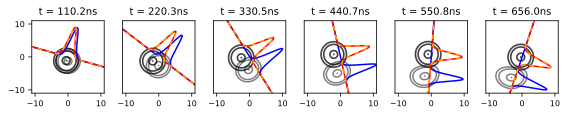

In [48]:
t_indices = [22, 44, 66,88,110,131]
num_times = len(t_indices)
fig, axes = plt.subplots(1,num_times,figsize = (8,2))
for col, (t_idx, ax) in enumerate(zip(t_indices,axes)):
    plot_one_t_slice(ax,t_idx)
    ax.set_xlim(-11,11)
    ax.set_ylim(-11,11)
    ax.set_aspect('equal')
    ax.set_title(f"t = {tlist[t_idx]:.1f}ns",fontdict = {'fontsize' : 10})
    if col >= 1:
        ax.set_yticks([])
    ax.tick_params(axis='both', which='major', labelsize=8)
    print(f'done:{col}')

plt.tight_layout()
fig.savefig('fig02.pdf')

In [49]:
def calculate_SNR(t_indices):
    A_leak_list = [] 
    mu_leak_list = []
    sigma_leak_list = []
    A_compu_list = []
    mu_compu_list = []
    sigma_compu_list = []

    leak_fit_accuracies = []
    compu_fit_accuracies = []
    for t_idx in tqdm(t_indices,desc = 'looping over'):
        q_values_leak = get_q_value(ql = 0 , t_idx =t_idx)
        q_values_compu = get_q_value(ql = 1 , t_idx =t_idx)
        theta = optimize_theta(q_values_leak,q_values_compu)
        theta = np.array([theta])
        y_leak = radon(q_values_leak,theta=theta).flatten()
        y_compu = radon(q_values_compu,theta=theta).flatten()

        A_leak, mu_leak, sigma_leak = fit_gaussian(y_leak)
        A_compu, mu_compu, sigma_compu = fit_gaussian(y_compu)

        A_leak_list.append(A_leak)
        mu_leak_list.append(mu_leak)
        sigma_leak_list.append(sigma_leak)
        A_compu_list.append(A_compu)
        mu_compu_list.append(mu_compu)
        sigma_compu_list.append(sigma_compu)

        RSS, R_squared, RMSE = get_fit_accuracy(y_leak, A_leak, mu_leak, sigma_leak )
        leak_fit_accuracies.extend([RSS, R_squared, RMSE])

        RSS, R_squared, RMSE = get_fit_accuracy(y_compu, A_compu, mu_compu, sigma_compu )
        compu_fit_accuracies.extend([RSS, R_squared, RMSE])
    
    return A_leak_list, mu_leak_list, sigma_leak_list, A_compu_list, mu_compu_list, sigma_compu_list, leak_fit_accuracies, compu_fit_accuracies


In [50]:
A_leak_list, mu_leak_list, sigma_leak_list, A_compu_list, mu_compu_list, sigma_compu_list, leak_fit_accuracies, compu_fit_accuracies = calculate_SNR(np.arange(132))

looping over:  12%|█▏        | 16/132 [01:30<11:02,  5.71s/it]ackages/skimage/transform/radon_transform.py: 74

In [ ]:
data = (A_leak_list, mu_leak_list, sigma_leak_list, A_compu_list, mu_compu_list, sigma_compu_list, leak_fit_accuracies, compu_fit_accuracies)
with open('numbers_for_SNR_5000traj.pkl', 'wb') as f:
    pickle.dump(data,f)

In [15]:
with open('numbers_for_SNR_5000traj.pkl', 'rb') as file:
    (A_leak_list, mu_leak_list, sigma_leak_list, A_compu_list, mu_compu_list, sigma_compu_list, leak_fit_accuracies, compu_fit_accuracies) = pickle.load(file)

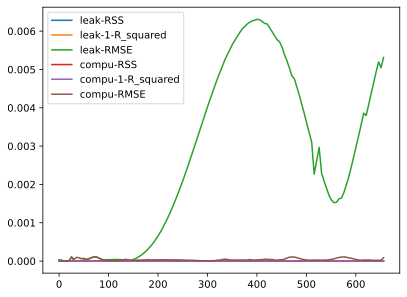

In [16]:
for item, level in zip([ leak_fit_accuracies, compu_fit_accuracies],["leak",'compu']):
    arr = np.array(item).reshape(-1,3)
    RSS = arr[:,0]
    R_squared = arr[:,1]
    RMSE = arr[:,2]
    plt.plot(tlist,RSS, label=f"{level}-RSS")
    plt.plot(tlist,1-R_squared, label=f"{level}-1-R_squared")
    plt.plot(tlist,RMSE, label=f"{level}-RMSE")
plt.legend()
# plt.ylim(-1e-5,1e-4)

NameError: name 'q_values_compu' is not defined

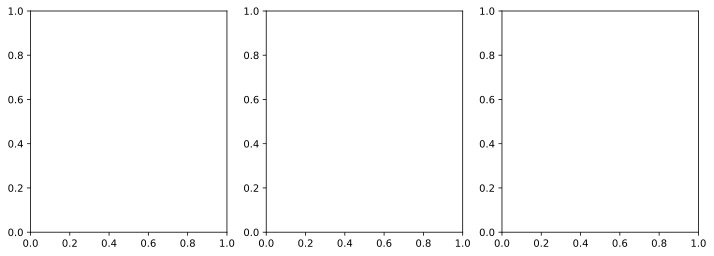

In [17]:
fig,axes = plt.subplots(1,3,figsize = (12,4))


t_idx = -1

# 1 plot the q-function contors
q_values_leak = get_q_value(ql = 0 , t_idx =t_idx)

# 2 optimize theta
theta = optimize_theta(q_values_leak,q_values_compu)
y_leak = radon(q_values_leak,theta=np.array([theta])).flatten()

A_leak, mu_leak, sigma_leak = fit_gaussian(y_leak)
y_fit = gaussian(xvec, A_leak, mu_leak, sigma_leak)

axes[0].plot(xvec, y_leak,color='blue',alpha= 0.7,label = 'leakage marginal')
axes[0].plot(xvec, y_fit,color='red',alpha= 0.7,label = 'fitted gaussian')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-12,1e1)
axes[0].legend()

cdf = np.cumsum(y_leak)
cdf_normalized = cdf / np.sum(y_leak)

axes[1].plot(cdf_normalized,label = 'leakage marginal cummulative density')
axes[1].plot(1-cdf_normalized,label = ' 1- leakage marginal cummulative density')
axes[1].legend()
axes[2].plot(cdf_normalized,label = 'leakage marginal cummulative density')
axes[2].plot(1-cdf_normalized,label = ' 1- leakage marginal cummulative density')
axes[2].set_ylim(0,5e-4)
axes[2].legend()

plt.title("is the marginal a gaussian?")

In [180]:
np.sqrt(kappa)

0.03162277660168379

In [18]:
contrast = np.abs(results[1].expect[0]-results[0].expect[0])
contrast = np.array(contrast)

weight = contrast
# weight[:] = 0
# weight = np.ones_like(contrast)#using a uniform weight can degrade the SNR

mu = 0.25


weight = weight/np.sqrt(np.trapz(weight**2,tlist))

integrated_contrast =  np.sqrt(mu)*scipy.integrate.cumulative_trapezoid(contrast*weight, tlist) #* np.sqrt(kappa) $ kappa cancels, doesn't affect snr
integrated_variance_leakage = scipy.integrate.cumulative_trapezoid(np.array(sigma_leak_list)**2 *weight, tlist) #*kappa 
integrated_variance_compu = scipy.integrate.cumulative_trapezoid(np.array(sigma_compu_list)**2 *weight, tlist) # *kappa 

integrated_variance = np.sqrt(integrated_variance_leakage + integrated_variance_compu)
snr = integrated_contrast / integrated_variance
error = erfc(snr/2)

Text(0.5, 1.0, 'integrated_variance')

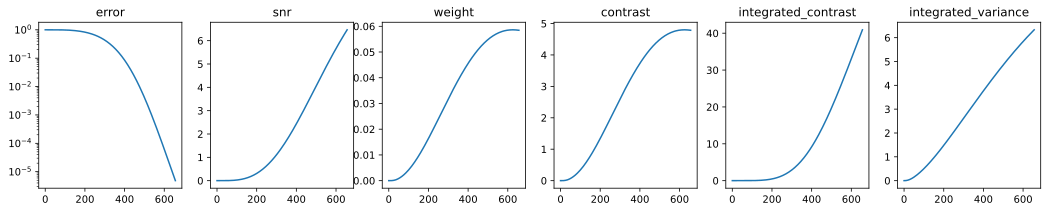

In [19]:
fig, axes = plt.subplots(1,6,figsize = (18,3))
axes[0].plot(tlist,np.insert(error, 0, 1) )
axes[0].set_title('error')
axes[0].set_yscale('log')

axes[1].plot(tlist, np.insert(snr, 0, 0))
axes[1].set_title('snr')

axes[2].plot(tlist, weight)
axes[2].set_title('weight')

axes[3].plot(tlist, contrast )
axes[3].set_title('contrast')

axes[4].plot(tlist, np.insert(integrated_contrast, 0, 0)  )
axes[4].set_title('integrated_contrast')

axes[5].plot(tlist, np.insert(integrated_variance, 0, 0)  )
axes[5].set_title('integrated_variance')

In [20]:
np.trapz(weight**2,tlist)

1.0

Text(0.5, 0, 'snr')

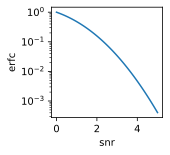

In [21]:
fig, ax = plt.subplots(figsize=(2,2))
example_snr_list = np.linspace(0,5,100)
example_error_list = erfc(example_snr_list/2)
plt.plot(example_snr_list,example_error_list)
plt.yscale('log')
plt.ylabel('erfc')
plt.xlabel('snr')

# computational states

In [7]:
def truncate_to_level_1_and_2(state):
    arr = state.full()
    arr= arr[1:3,1:3]
    return qutip.Qobj(arr)


In [8]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j *one).unit()]

def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        fid.append(qutip.fidelity(gate*dm*gate.dag(), ket_ideal))
    return 1-sum(fid)/len(fid)


Processing: 100%|██████████| 132/132 [00:11<00:00, 11.48it/s]


Text(0.5, 1.0, 'infidelity')

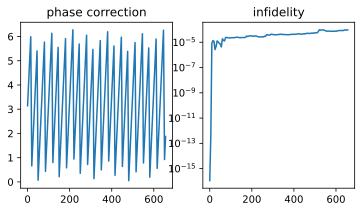

In [12]:


infidelity = []
phase = []
original_phase = -2*np.pi*tlist* 0.030180212858487328
original_phase = original_phase % (2*np.pi) 

for idx in tqdm(range(len(tlist)), desc='Processing'):
    dms = [truncate_to_level_1_and_2(result.states_in_product_basis[idx].ptrace(0)) for result in results[1:]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    opt_result = minimize(objective_function,x0=  [original_phase[idx]],bounds = [(0, 2*np.pi)], method="Powell")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x[0])
    

fig, axes = plt.subplots(1,2,figsize = (6,3))
axes[0].plot(tlist,phase)
axes[0].set_title('phase correction')
axes[1].plot(tlist,infidelity)
axes[1].set_yscale('log')
axes[1].set_title('infidelity')


fitted frequency 0.1896279780105522
frequency from eigenvalues:0.18964626624901787


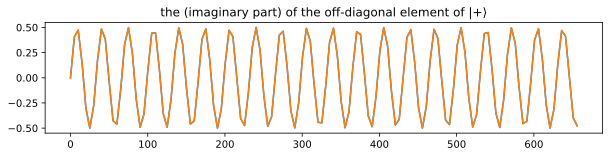

In [13]:
complex_num  = np.array([ truncate_to_level_1_and_2(results[3].states_in_product_basis[idx].ptrace(0))[1,0] for idx in range(len(tlist))])
t_indices = list(range(len(tlist)))

def sin(xvec, A, omega):
    return A * np.sin(omega*xvec)

popt, pcov = curve_fit(sin, tlist, complex_num.imag, p0=[0.5, 0.0605  * np.pi]) 
print(f"fitted frequency {popt[1]}")
print(f"frequency from eigenvalues:{2*np.pi*(system.evals[system.product_to_dressed[(2,0)]]-system.evals[system.product_to_dressed[(1,0)]])}")

plt.subplots(figsize = (10,2))
plt.title(rf"the (imaginary part) of the off-diagonal element of |+$\rangle$")
plt.plot(tlist,complex_num.imag)
plt.plot(tlist,sin(tlist, popt[0], popt[1]))

Processing: 100%|██████████| 132/132 [00:03<00:00, 34.27it/s]


Text(0.5, 1.0, 'infidelity')

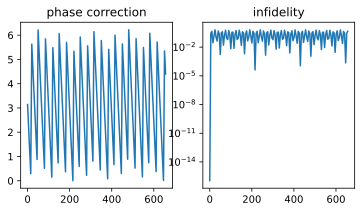

In [14]:
infidelity = []
original_phase = -2*np.pi*tlist*(system.evals[system.product_to_dressed[(2,0)]]-system.evals[system.product_to_dressed[(1,0)]]) + np.pi
original_phase = original_phase % (2*np.pi) 
for idx in tqdm(range(len(tlist)), desc='Processing'):
    dms = [truncate_to_level_1_and_2(result.states_in_product_basis[idx].ptrace(0)) for result in results[1:]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    infidelity.append(objective_function([original_phase[idx]]))
    phase.append(opt_result.x[0])


fig, axes = plt.subplots(1,2,figsize = (6,3))
axes[0].plot(tlist,original_phase)
axes[0].set_title('phase correction')
axes[1].plot(tlist,infidelity)
axes[1].set_yscale('log')
axes[1].set_title('infidelity')
